# OTT 멤버십 이탈 예측을 위한 EDA 분석(8-11페이지)

[전자상거래(e-Commerce) 및 온라인 거래 이용 현황]

[방송통신 서비스 가입 및 지출 현황]

## 분석 목적

본 분석은 OTT 멤버십 이용자의 이탈 여부(is_churned)와 주요 설문 변수 간의 관계를 탐색하여
이탈 가능성과 관련된 주요 특징(feature)을 탐색하는 것을 목적으로 한다.

설문 데이터에서 추출한 변수들을 기반으로 **상관분석(Correlation Analysis)**을 수행하였으며,
이탈 여부와 절대 상관계수 0.1 이상을 가지는 변수를 주요 분석 대상으로 선정하였다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('../../00_data/01_interim/selected_data_2023.csv')

df.head()

C:\Users\minhakim\AppData\Local\Temp\ipykernel_29168\3966660411.py:1: DtypeWarning: Columns (0: p__d26019, 1: p__d26064, 2: p__d26068, 3: p__d27007, 4: p__d28003, 5: p__d22007, 6: p__d26062, 7: p__a03012, 8: p__l01012, 9: p__l01015, 10: p__l01028, 11: p__k06004, 12: p__relig3, 13: p__d26088) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../00_data/01_interim/selected_data_2023.csv')


,YEAR,OPID,pid,hid,housenum,p__wt,p__wt2,p__wt_org,p__wt_org2,KMPS10,...,p__i02008,p__i02012,p__i02013,p__i02014,p__i02015,p__i02016,p__l01038,p__l01042,netflix_next,is_churned
0,2023,10002,10002,100,2,0.077611,0.119846,0.225981,1.416785,NaN,...,1.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0
1,2023,40002,40002,400,2,1.249054,NaN,0.080760,NaN,NaN,...,8.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0
2,2023,40004,40004,400,4,1.421301,NaN,0.086053,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,1.0,0
3,2023,100001,100001,1000,1,2.413607,2.733948,4.353450,10.114858,NaN,...,4.0,3.0,NaN,NaN,NaN,NaN,6.0,NaN,1.0,0
4,2023,100002,100002,1000,2,2.331754,2.642048,3.646194,5.876653,NaN,...,8.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0


In [15]:
cols = [

    # 인터넷 전용 은행 사용여부 (1 예 2 아니오) (문13)
    "p__i02001",

    # 모바일 간편 송금 서비스 사용여부 (문14)
    "p__i02003",

    # 월평균 휴대폰 이용 총 금액 (문15)
    "p__c01001", "p__c01002", "p__c01003", "p__c01004",

    # 휴대폰 결합상품 가입 여부 (문16)
    "p__c02003",

    # 휴대폰 요금 부담자 (문17)
    "p__c02001",

    # 주로 이용하는 OTT 서비스 유형 (문19)
    "p__d26051", "p__d26052", "p__d26053", "p__d26056", "p__d26058", "p__d26061",

    # 온라인 디지털 콘텐츠 이용여부 (문20)
    "p__c05049", "p__c05050", "p__c05051", "p__c05052",

    # 타겟 컬럼
    "is_churned",


]

# 원본 컬럼과 존재/부재하는 컬럼 확인
exist_cols = [c for c in cols if c in df.columns]
missing_cols = [c for c in cols if c not in df.columns]

cols_df = df[exist_cols].copy()

print("원본 df shape:", df.shape)
print("존재 컬럼 수:", len(exist_cols))
print("df shape:", cols_df.shape)
if missing_cols:
    print("\n[주의] CSV에 없는 컬럼:", missing_cols)

cols_df.head()


원본 df shape: (2280, 1522)
존재 컬럼 수: 19
df shape: (2280, 19)


,p__i02001,p__i02003,p__c01001,p__c01002,p__c01003,p__c01004,p__c02003,p__c02001,p__d26051,p__d26052,p__d26053,p__d26056,p__d26058,p__d26061,p__c05049,p__c05050,p__c05051,p__c05052,is_churned
0,1.0,1.0,47.0,5.0,0.0,1.0,1.0,4.0,1.0,2.0,1.0,NaN,4.0,2.0,2,2,2,2,0
1,2.0,1.0,30.0,4.0,30.0,4.0,1.0,1.0,1.0,2.0,2.0,NaN,NaN,NaN,2,2,2,2,0
2,2.0,2.0,34.0,4.0,0.0,1.0,1.0,4.0,1.0,2.0,2.0,NaN,NaN,NaN,2,2,2,2,0
3,1.0,1.0,31.0,4.0,26.0,3.0,1.0,1.0,2.0,2.0,1.0,NaN,5.0,3.0,1,1,1,1,0
4,1.0,1.0,34.0,4.0,15.0,2.0,1.0,1.0,1.0,2.0,2.0,NaN,NaN,NaN,1,1,1,1,0


In [16]:
# 타겟 컬럼 is_chruned 확인(0: 유지, 1: 해지)
df["is_churned"].value_counts(dropna=False)

is_churned
0    1455
1     825
Name: count, dtype: int64

In [23]:
# 상관계수 구하기
corr = cols_df.corr(numeric_only=True)
churn_corr = corr['is_churned'].drop('is_churned')

important_features = churn_corr[abs(churn_corr) >= 0.05]

important_features = important_features.sort_values()

print(important_features)

p__d26056   -0.256034
p__c01001   -0.110281
p__c01002   -0.109561
p__d26058   -0.080220
p__c05051    0.052701
p__i02003    0.061393
p__i02001    0.106647
Name: is_churned, dtype: float64


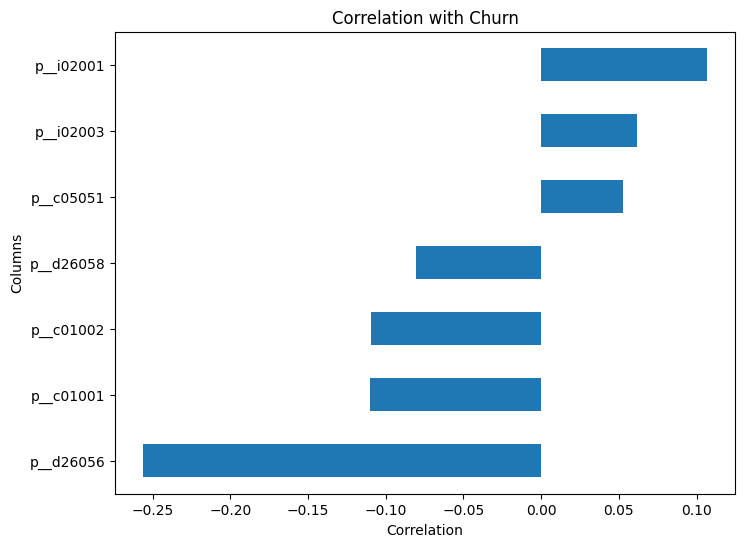

In [25]:
# 시각화
important_features.plot(kind='barh', figsize=(8,6))

plt.title('Correlation with Churn')
plt.xlabel('Correlation')
plt.ylabel('Columns')

plt.show()

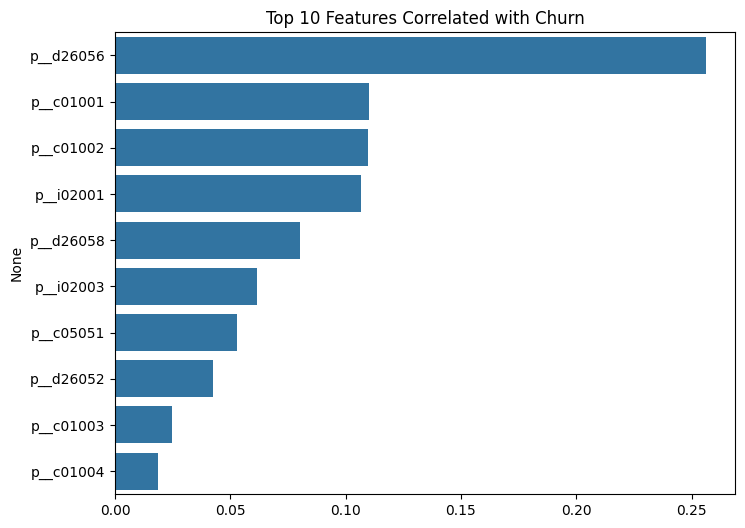

In [26]:
# 중요한 컬럼 구하기
top_corr = churn_corr.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top_corr.values, y=top_corr.index)

plt.title('Top 10 Features Correlated with Churn')

plt.show()

In [32]:
pd.crosstab(
    corr_df['p__d26056'],
    corr_df['is_churned'],
    normalize='index'
)

is_churned,0,1
p__d26056,,
1.0,0.550000,0.450000
2.0,0.571429,0.428571
3.0,0.782609,0.217391
4.0,1.000000,0.000000
5.0,0.666667,0.333333
7.0,1.000000,0.000000


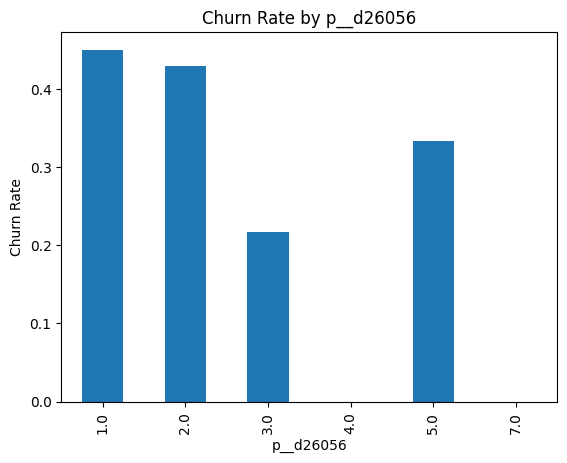

In [33]:
churn_rate = pd.crosstab(
    corr_df['p__d26056'],
    corr_df['is_churned'],
    normalize='index'
)[1]

churn_rate.plot(kind='bar')

plt.title('Churn Rate by p__d26056')
plt.ylabel('Churn Rate')

plt.show()

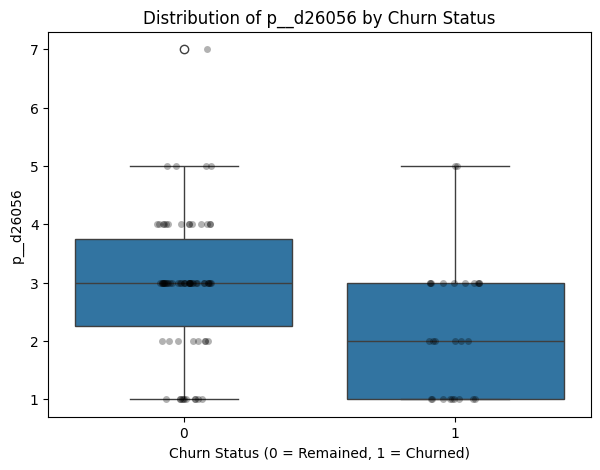

In [40]:
plt.figure(figsize=(7,5))

# 박스플롯
sns.boxplot(
    x='is_churned',
    y='p__d26056',
    data=corr_df,
)

# 실제 데이터 분포 점 표시
sns.stripplot(
    x='is_churned',
    y='p__d26056',
    data=corr_df,
    color='black',
    alpha=0.3,
    jitter=True
)

plt.title('Distribution of p__d26056 by Churn Status')
plt.xlabel('Churn Status (0 = Remained, 1 = Churned)')
plt.ylabel('p__d26056')

plt.show()